# **Project Background**

My final project is about the ICC ODI Cricket World Cup data from 1975-2019. Cricket is a very popular sport and is played by many countries overseas, this project will focus on the One Day International format which typically is 50 overs long, with 6 balls played per over. Over 20 countries have played in this tournament, 6 of them playing every year since its inception.  

The dataset I will be using is titled CRICKET WORLD CUP SCORES(1975-2019). It contains the scores o all the cricket matches played in the world cup sources from the ICC Website and Cricbuzz website.The selected dataset has over 1000 rows of data, describing all the matches in each world cup year, the number of runs made in the game, wickets taken and lost, who played in the match, the venue, and overall world cup winner. The dataset can be found on Kaggle.com at https://www.kaggle.com/datasets/amalab182/cricket-world-cup-scores1975-2019

# **Questions Posed**

Q1 - Does the host location present an advantage to certain teams? For teams who have won more than once, do they tend to win in the same host location or is there no correlation between the two?

Q2 - Who are the teams to beat? Which teams have the lowest amount of losses and does that correlate to more overall world cup wins?

Q3 - Which venues/locations had the best pitch? How do runs made on each location compare to each other and is there a specific location that's most advantageous?

# **Importing Modules**

In [124]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import math
import datetime
import sqlite3

# **ICC Cricket ODI World Cup 1975-2019 Dataset**

In [125]:
cricket = pd.read_csv('cricketworldcup.csv')

conn = sqlite3.connect(':memory:')
cricket.to_sql('cricket', conn, index=False)

print(f"cricket table: {len(cricket)} rows, columns: {list(cricket.columns)}")

cricket table: 873 rows, columns: ['YEAR', 'TEAM', 'RUNS_SCORED', 'WICKETS_LOST', 'WICKETS_TAKEN', 'AGAINST', 'WINNER', 'VENUE', 'HOST_COUNTRY', 'CHAMPION']


## Column Header Descriptions

- Year - Year of the World Cup
- Team - Playing Team
- Runs Scored - Runs scored by the team
- Wickets Lost - Wickets lost while batting
- Wickets Taken - Wickets taken while bowling
- Against - Opposing Team
- Winner - Winner of the current match
- Venue - Location of the match
- Champion - Winner of the tournament

## Filtering the Data

The dataset found on Kaggle was cleaned and filtered to become usable for this project. First, any extra rows were deleted to prevent errored values when sorting the values into a tables. Next, the "RESULT" column was changed into "WINNER", changing the value to the name of the winner of that match rather than the result "WIN" or "LOST" applying to the respective team. The last column was subsequently renamed "CHAMPION" as it desribes the overall champion of the tournament for the year in which that match was played.

Additionally, as many matches were canceled or abandoned due to weather, there were some matches that had no result. In the dataset they were marked with "NR" in all of the columns. To make the sorting process easier, I removed all of the NR games and focused only on games that were played.

## Initial Insights

Using basic functions like mean and sum we can look at some initial results from our dataset. Any columns with 

In [126]:
result = pd.read_sql_query("""
    SELECT AVG(RUNS_SCORED) as avg_runs_scored, SUM(RUNS_SCORED) as sum_runs_scored, MIN(RUNS_SCORED) as min_runs_scored, MAX(RUNS_SCORED) as MAX_runs_scored, AVG(WICKETS_LOST) as avg_wickets_lost, AVG(WICKETS_TAKEN) as avg_wickets_taken
    FROM cricket
""", conn)
result.head()

,avg_runs_scored,sum_runs_scored,min_runs_scored,MAX_runs_scored,avg_wickets_lost,avg_wickets_taken
0,219.07331,191251,36,417,7.24055,7.235968


From our results, we can see that on average each game is around 212, with the minimum being 36 and maximum being 417. Additionally we can see that the average wickets lost was around 7 while the average wickets taken was also around 7.

# **Question 1**

### Does the host location present an advantage to certain teams? For teams who have won more than once, do they tend to win in the same host location or is there no correlation between the two?

# **Question 2**

### Who are the teams to beat? Which teams have the lowest amount of losses and does that correlate to more overall world cup wins?

# **Question 3**

### Which venues/locations had the best pitch? How do runs made on each location compare to each other and is there a specific location that's most advantageous?

In [127]:
result = pd.read_sql_query("""
    SELECT VENUE, HOST_COUNTRY, AVG(RUNS_SCORED) as avg_runs_scored
    FROM cricket
    GROUP BY VENUE
    ORDER BY avg_runs_scored DESC
    LIMIT 10
""", conn)
print(result)

           VENUE HOST_COUNTRY  avg_runs_scored
0          KANDY         ASIA       326.000000
1        SWANSEA      ENGLAND       313.000000
2   NEW PLYMOUTH       AUS/NZ       312.500000
3         NELSON       AUS/NZ       303.000000
4      BENGALURU    INDIA/PAK       270.214286
5        TAUNTON      ENGLAND       269.583333
6  VISAKHAPATNAM         ASIA       255.500000
7       CANBERRA       AUS/NZ       254.750000
8       BRIGHTON      ENGLAND       253.500000
9         KANPUR    INDIA/PAK       250.833333


In [128]:
host_counts = result['HOST_COUNTRY'].value_counts()
print(host_counts)

HOST_COUNTRY
ENGLAND      3
AUS/NZ       3
ASIA         2
INDIA/PAK    2
Name: count, dtype: int64


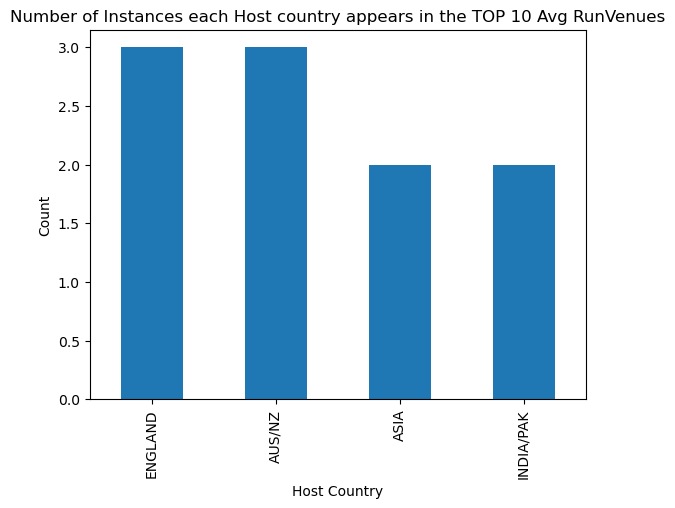

In [131]:
host_counts.plot(kind='bar')

plt.xlabel('Host Country')
plt.ylabel('Count')
plt.title('Number of Instances each Host country appears in the TOP 10 Avg Run Venues')

plt.show()

In [134]:
result = pd.read_sql_query("""
    SELECT HOST_COUNTRY, AVG(RUNS_SCORED) as avg_runs_scored
    FROM cricket
    GROUP BY HOST_COUNTRY
    ORDER BY avg_runs_scored DESC
""", conn)
print(result)

   HOST_COUNTRY  avg_runs_scored
0     INDIA/PAK       232.907407
1        AUS/NZ       227.065089
2       ENGLAND       221.783688
3          ASIA       218.849398
4   WEST INDIES       209.147059
5  SOUTH AFRICA       200.950000


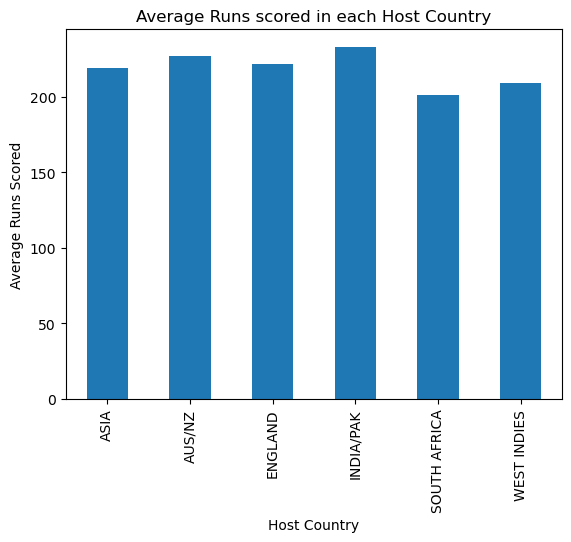

In [140]:
result.groupby('HOST_COUNTRY')['avg_runs_scored'].mean().plot(kind='bar')
plt.xlabel('Host Country')
plt.ylabel('Average Runs Scored')
plt.title('Average Runs scored in each Host Country')
plt.show()

1.1.3


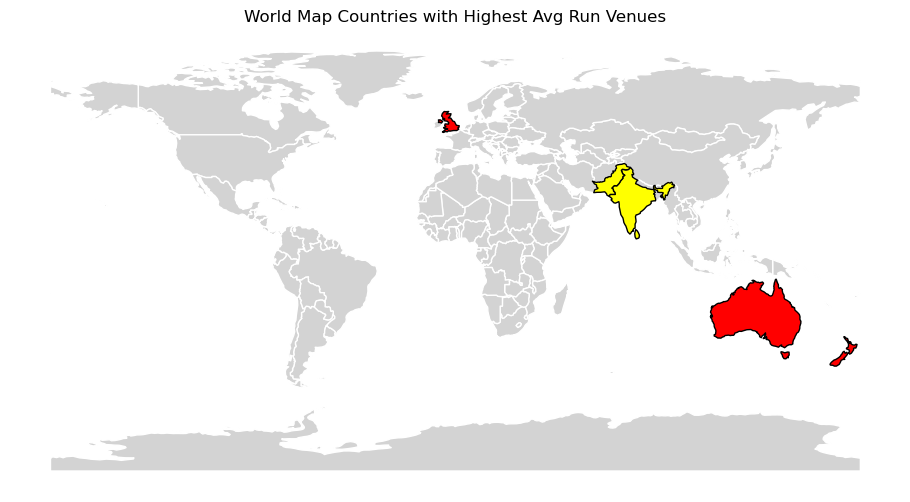

In [141]:

import geopandas as gpd
print(gpd.__version__)
import geodatasets
import matplotlib.pyplot as plt

# Load world countries dataset
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Countries to highlight
twotimes = ['Sri Lanka', 'India', 'Pakistan']
threetimes = ['United Kingdom', 'New Zealand', 'Australia']
# Create highlight column
world['high'] = world['NAME'].isin(threetimes)
world['light'] = world['NAME'].isin(twotimes)
# Plot
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(ax=ax, color='lightgray', edgecolor='white')
world[world['high']].plot(ax=ax, color='red', edgecolor='black')
world[world['light']].plot(ax=ax, color='yellow', edgecolor='black')

ax.set_title('World Map Countries with Highest Avg Run Venues')
ax.axis('off')

plt.show()

## **REFLECTION**

In looking at the graph and plot from Question 3, we can see that there isn't just one host country or venue that reigns supreme. Even in counting the number of times the host countries/regions pop up in the top ten, we see that two regions(England and Aus/NZ) appreared 3 times and two regions(India/Pak, Asia) appeared 2 times. No country appears more than the other. This indicated that the venues and pitch are most likely well balanced.